In [10]:
%load_ext autoreload
%autoreload 2

In [4]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from data_utils import load_data, split_days, calculate_pv_benchmark
from simulation import simulate_day, E_INIT, E_MAX, E_MIN
from optimizers.annealing import run_sa

# --- 1. Przygotowanie danych ---
df = load_data("../solar_base.csv")
days = split_days(df)

test_days = days[179:185] 
pv_only_profit = calculate_pv_benchmark(test_days)

annual_hybrid_profit = 0.0
e_state = E_INIT

# Słownik do przechowywania trajektorii dla każdego dnia (potrzebne do wykresów)
saved_results = {}

print("=" * 60)
print(f" Uruchamiam optymalizację dla {len(test_days)} dni...")
print("=" * 60)
t0 = time.perf_counter()

for i, (date, price, pv) in enumerate(test_days):
    t_start_sa = time.perf_counter()
    # Pobieramy u_opt ORAZ historię optymalizacji
    u_opt, sa_history, sa_history_current, sa_history_u = run_sa(price, pv, e_init=e_state, seed=42+i)
    t_end_sa = time.perf_counter()
    
    day_profit, soc_trajectory = simulate_day(u_opt, price, pv, e_init=e_state, penalize=False)
    
    annual_hybrid_profit += day_profit
    old_e = e_state
    e_state = soc_trajectory[-1]
    
    # Zapisujemy komplet danych pod wykresy
    saved_results[i] = {
        "date": date,
        "price": price,
        "pv": pv,
        "u_opt": u_opt,
        "soc": soc_trajectory,
        "sa_history": sa_history,
        "sa_history_current": sa_history_current, 
        "sa_history_u": sa_history_u,
        "profit": day_profit
    }
    
    print(f"▶ Dzień {i+1}/{len(test_days)} ({date}) Zrobiony w {t_end_sa - t_start_sa:.1f}s | Zysk: {day_profit:+,.2f} PLN")

execution_time = time.perf_counter() - t0

# --- 2. FUNKCJE WIZUALIZACYJNE (NA SLAJDY I DO RAPORTU) ---

def plot_best_sa_convergence(day_idx, skip_first_n=50, ymin=None):
    """Rysuje krzywą zbieżności algorytmu, ignorując początkowe, ekstremalne kary."""
    res = saved_results[day_idx]
    full_history = res["sa_history"]
    
    # Odcięcie początkowych, zaburzających skalę epok
    plot_data = full_history[skip_first_n:]
    x_axis = range(skip_first_n, len(full_history))
    
    plt.figure(figsize=(10, 4))
    plt.plot(x_axis, plot_data, color="#e63946", linewidth=2.5, label="Najlepsze dopasowanie (Zysk)")
    
    plt.title(f"Krzywa zbieżności SA (od {skip_first_n} epoki) – Dzień {res['date']}", fontsize=12, fontweight='bold')
    plt.xlabel("Krok chłodzenia (Epoka)", fontsize=10)
    plt.ylabel("Funkcja celu [PLN]", fontsize=10)
    
    # Opcjonalne: Sztywne ustawienie dolnej granicy osi Y
    if ymin is not None:
        plt.ylim(bottom=ymin)
        
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

def plot_sa_convergence(day_idx, skip_first_n=50, ymin=None):
    """Rysuje zaawansowaną krzywą zbieżności: błądzenie + rekordy."""
    res = saved_results[day_idx]
    
    # Pobieramy obie historie
    best_history = res["sa_history"][skip_first_n:]
    curr_history = res["sa_history_current"][skip_first_n:]
    x_axis = range(skip_first_n, skip_first_n + len(best_history))
    
    plt.figure(figsize=(10, 4))
    
    # 1. Rysujemy błądzenie (stan bieżący) jako tło (jasnoniebieski, cieńszy)
    plt.plot(x_axis, curr_history, color="#8ecae6", linewidth=1.5, alpha=0.8, 
             label="Aktualny stan (Eksploracja)")
    
    # 2. Rysujemy rekordy (stan najlepszy) na pierwszym planie (czerwony, grubszy)
    plt.plot(x_axis, best_history, color="#e63946", linewidth=2.5, 
             label="Najlepsze dopasowanie (Rekord)")
    
    plt.title(f"Dynamika zbieżności Wyżarzania Symulowanego – Dzień {res['date']}", 
              fontsize=12, fontweight='bold')
    plt.xlabel("Krok chłodzenia (Epoka)", fontsize=10)
    plt.ylabel("Funkcja celu [PLN]", fontsize=10)
    
    if ymin is not None:
        plt.ylim(bottom=ymin)
        
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

def plot_daily_dispatch(day_idx):
    """Rysuje pełny dobowy profil pracy układu hybrydowego (Ceny, PV, Bateria, SoC)."""
    res = saved_results[day_idx]
    hours = np.arange(24)
    
    fig = plt.figure(figsize=(14, 8))
    gs = gridspec.GridSpec(2, 1, hspace=0.3, height_ratios=[1, 1.2])
    
    # Panel 1: Otoczenie rynkowe (Ceny i Generacja PV)
    ax0 = fig.add_subplot(gs[0])
    ax0.bar(hours, res["price"], color="#457b9d", alpha=0.5, width=0.6, label="Cena energii [PLN/MWh]")
    ax0.set_ylabel("Cena na giełdzie [PLN/MWh]", color="#457b9d", fontweight='bold')
    ax0.axhline(0, color="black", linewidth=0.8, linestyle="-")
    ax0.tick_params(axis='y', labelcolor="#457b9d")
    
    ax0_twin = ax0.twinx()
    ax0_twin.plot(hours, res["pv"], color="#f4a261", linewidth=2.5, marker='o', label="Generacja PV [MW]")
    ax0_twin.set_ylabel("Moc generowana z PV [MW]", color="#f4a261", fontweight='bold')
    ax0_twin.tick_params(axis='y', labelcolor="#f4a261")
    
    ax0.set_title(f"Profil operacyjny systemu hybrydowego – Dzień {res['date']} (Zysk: {res['profit']:,.2f} PLN)", fontsize=14, fontweight='bold')
    ax0.set_xticks(hours)
    ax0.grid(True, linestyle="--", alpha=0.3)
    
    # Połączone legendy dla Panelu 1
    lines, labels = ax0.get_legend_handles_labels()
    lines2, labels2 = ax0_twin.get_legend_handles_labels()
    ax0.legend(lines + lines2, labels + labels2, loc="upper left")

    # Panel 2: Zachowanie baterii (Decyzje u[t] oraz profil naładowania SoC)
    ax1 = fig.add_subplot(gs[1])
    
    # Kolory słupków: zielone dla ładowania, czerwone dla rozładowania
    colors = ['#2a9d8f' if u >= 0 else '#e63946' for u in res["u_opt"]]
    ax1.bar(hours, res["u_opt"], color=colors, alpha=0.8, width=0.6, label="Sterowanie baterii u[t] [MW] (+ ładuje, - rozładuje)")
    ax1.set_ylabel("Moc pracy baterii [MW]", color="black", fontweight='bold')
    ax1.set_xlabel("Godzina doby", fontsize=11)
    ax1.set_ylim(-60, 60)
    ax1.axhline(0, color="black", linewidth=0.8)
    ax1.grid(True, linestyle="--", alpha=0.3)
    
    ax1_twin = ax1.twinx()
    ax1_twin.plot(np.arange(25), res["soc"], color="black", linestyle="--", linewidth=2, marker='s', markersize=4, label="Stan naładowania SoC [MWh]")
    ax1_twin.set_ylabel("Magazyn SoC [MWh]", color="black", fontweight="bold")
    ax1_twin.set_ylim(0, E_MAX * 1.1)
    ax1_twin.axhline(E_MAX, color="red", linestyle=":", alpha=0.7, label="E_MAX (Limit)")
    ax1_twin.axhline(E_MIN, color="red", linestyle=":", alpha=0.7, label="E_MIN (Limit)")
    
    ax1.set_xticks(hours)
    
    # Połączone legendy dla Panelu 2
    lines3, labels3 = ax1.get_legend_handles_labels()
    lines4, labels4 = ax1_twin.get_legend_handles_labels()
    ax1.legend(lines3 + lines4, labels3 + labels4, loc="upper left")
    
    plt.tight_layout()
    plt.show()
import seaborn as sns
import matplotlib.gridspec as gridspec
from matplotlib.colors import SymLogNorm # <--- Nieliniowa paleta

def plot_dynamic_evolution_panel(day_idx, skip_first_n=50, dynamic_cutoff_epoch=400):
    """
    Dwupanelowy wykres, który drastycznie powiększa fazę błądzenia
    I używa nieliniowej palety, aby wydobyć niewidoczne różnice wokół 0.
    """
    res = saved_results[day_idx]
    date = res["date"]
    price = res["price"]
    
    # --- PRZYCINANIE MATRYCY (Gęsty widok ewolucji błądzenia) ---
    # Bierzemy TYLKO pierwsze, gęste kroki (skip_first_n -> dynamic_cutoff_epoch)
    # Subsetujemy macierz: bierzemy epoki od skip_first_n DO dynamic_cutoff_epoch
    u_matrix = np.array(res["sa_history_u"])[skip_first_n:dynamic_cutoff_epoch]
    
    if u_matrix.shape[0] == 0:
        print(f"Błąd: cutoff_epoch ({dynamic_cutoff_epoch}) jest mniejszy niż skip_first_n ({skip_first_n}).")
        return

    # Konfiguracja Figury (Gridspec)
    fig = plt.figure(figsize=(14, 10))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 4], hspace=0.1)
    
    # --- PALETA KOLORÓW (Nieliniowo wyostrzony środek) ---
    # Używamy SymLogNorm (log-normalna wokół 0). 
    # Małe zmiany wokół 0 (np. 5 MW vs 15 MW) będą miały większe różnice w odcieniu.
    # To pomoże pokazać błądzenie w strefie "zamrożenia".
    norm = SymLogNorm(linthresh=3.0, linscale=1.5, vmin=-50, vmax=50, base=10)
    # Niestandardowa paleta (intensywniejsze kolory środka)
    cmap = sns.diverging_palette(10, 130, s=90, l=60, sep=20, as_cmap=True)

    # =========================================================================
    # PANEL GÓRNY: Profil Cenowy
    # =========================================================================
    ax_price = fig.add_subplot(gs[0])
    hours = np.arange(24)
    ax_price.bar(hours, price, color="#457b9d", alpha=0.6, width=0.7, label="Cena spot [PLN/MWh]")
    ax_price.set_ylabel("PLN/MWh", fontsize=11, fontweight='bold')
    
    # Tytuł kompozytowy
    ax_price.set_title(f"Kontekstowa analiza błądzenia harmonogramu (Faza dynamiczna) – Dzień {date}", 
                       fontsize=15, fontweight='bold', pad=15)
    
    ax_price.axhline(0, color="black", linewidth=0.8)
    ax_price.set_xticks(hours)
    ax_price.set_xticklabels([]) 
    ax_price.grid(True, axis='y', linestyle="--", alpha=0.3)
    ax_price.legend(loc="upper left")

    # =========================================================================
    # PANEL DOLNY: Heatmapa Ewolucji (Wydobyta dynamika błądzenia)
    # =========================================================================
    ax_heat = fig.add_subplot(gs[1])
    
    # Rysujemy heatmapę Z UŻYCIEM SymLogNorm (norm=norm)
    sns.heatmap(u_matrix, cmap=cmap, center=0, norm=norm,
                ax=ax_heat, cbar_kws={'label': 'Moc pracy baterii (Skala Log-Wyostrzona) [MW]'},
                yticklabels=False) 
    
    ax_heat.set_xlabel("Godzina doby (Profil rynkowy)", fontsize=12, fontweight='bold')
    ax_heat.set_ylabel("Powiększenie fazy błądzenia SA (Krok algorytmu / Epoka)", fontsize=12, fontweight='bold')
    
    ax_heat.set_xticks(np.arange(0.5, 24.5, 1))
    ax_heat.set_xticklabels(hours, fontsize=10)

    # --- NAPRAWA ESTETYKI OSI Y (Równe etykiety) ---
    num_epochs_plotted = u_matrix.shape[0]
    # Ręcznie definiujemy równe kroki (np. co 100 epok na gęstym widoku)
    y_tick_locations = np.linspace(0, num_epochs_plotted-1, num=5)
    y_tick_labels = np.linspace(skip_first_n, dynamic_cutoff_epoch-1, num=5, dtype=int)
    
    ax_heat.set_yticks(y_tick_locations + 0.5)
    ax_heat.set_yticklabels(y_tick_labels, rotation=0, fontsize=10)
    
    plt.tight_layout()
    plt.show()

 Uruchamiam optymalizację dla 6 dni...
▶ Dzień 1/6 (2025-07-01) Zrobiony w 15.5s | Zysk: +247,205.15 PLN
▶ Dzień 2/6 (2025-07-02) Zrobiony w 13.1s | Zysk: +249,779.86 PLN
▶ Dzień 3/6 (2025-07-03) Zrobiony w 13.3s | Zysk: +127,247.97 PLN
▶ Dzień 4/6 (2025-07-04) Zrobiony w 13.1s | Zysk: +162,840.37 PLN
▶ Dzień 5/6 (2025-07-05) Zrobiony w 13.2s | Zysk: +91,989.99 PLN
▶ Dzień 6/6 (2025-07-06) Zrobiony w 13.0s | Zysk: +96,930.30 PLN


In [23]:
saved_results[14]["sa_history"]

KeyError: 14

C:\Users\micha\AppData\Local\Temp\ipykernel_39144\2631814331.py:250: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


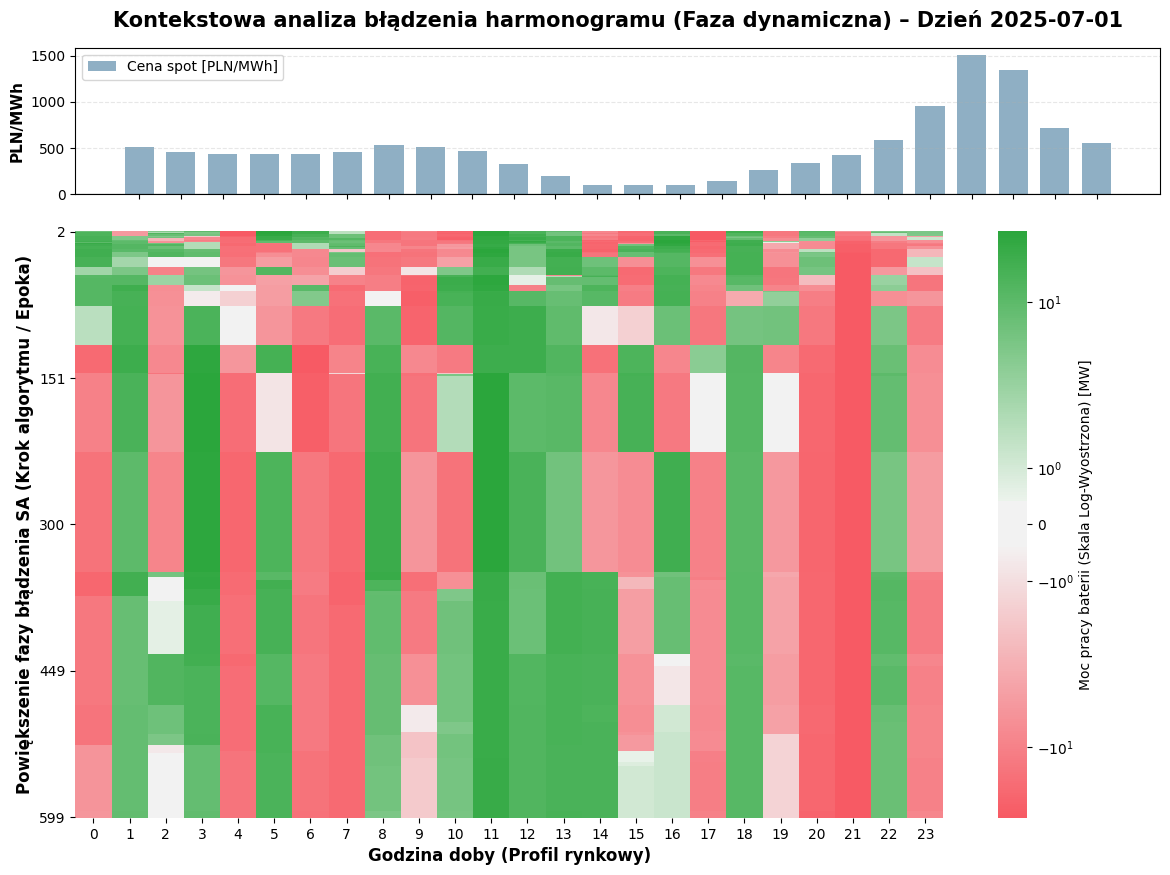

In [7]:
plot_dynamic_evolution_panel(day_idx = 0, skip_first_n=2,dynamic_cutoff_epoch=600)

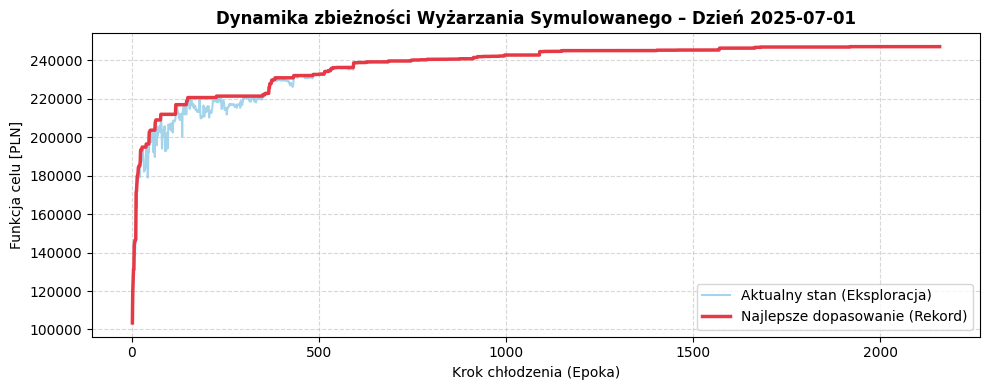

In [5]:
# Wizualizacja procesu optymalizacji
plot_sa_convergence(day_idx=0,skip_first_n=2)


C:\Users\micha\AppData\Local\Temp\ipykernel_33180\3567281116.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


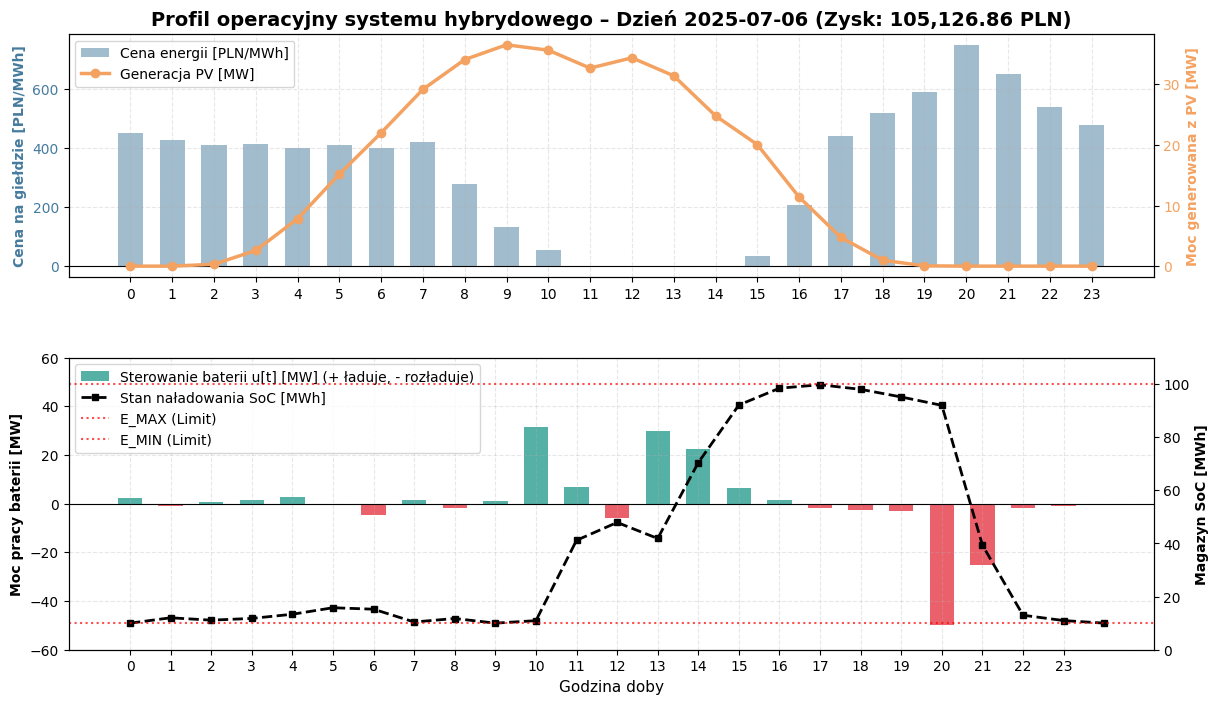

In [2]:

# Wizualizacja efektu końcowego (harmonogramu)
plot_daily_dispatch(day_idx=4)

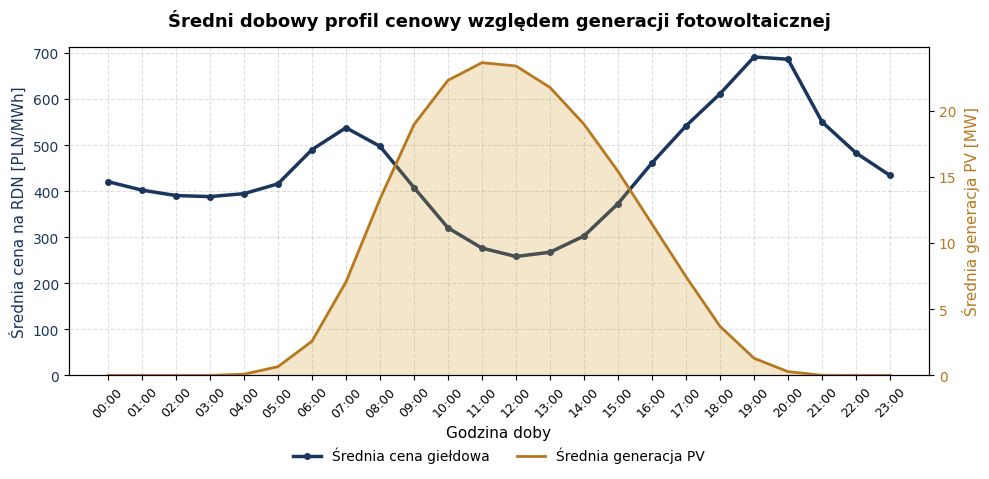

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Wczytanie i przygotowanie danych
df = pd.read_csv("../solar_base.csv", parse_dates=["datetime"])
df = df.sort_values("datetime").set_index("datetime")
df = df.resample("1h").mean().dropna(subset=["fix1_price"])
df["pv_mw"] = df["pv_mw"].fillna(0.0)

# Skalowanie PV do ustalonego rozmiaru farmy (50 MW)
SCALE_PV_MW = 50.0
pv_max = df["pv_mw"].max()
if pv_max > 0:
    df["pv_mw_scaled"] = df["pv_mw"] / pv_max * SCALE_PV_MW
else:
    df["pv_mw_scaled"] = 0.0

# 2. Agregacja do średniego profilu dobowego
df["hour"] = df.index.hour
daily_profile = df.groupby("hour")[["fix1_price", "pv_mw_scaled"]].mean()

# 3. Profesjonalna Wizualizacja Akademicka
fig, ax1 = plt.subplots(figsize=(10, 5))

# --- Subtelne, akademickie kolory ---
color_price = "#1A365D"    # Głęboki granatowy
color_pv_line = "#B7791F"  # Zgaszone złoto / ciemny ugier
color_pv_fill = "#D69E2E"  # Złoty z przezroczystością

# --- Lewa Oś: Średnia Cena na RDN ---
ax1.set_xlabel("Godzina doby", fontsize=11)
ax1.set_ylabel("Średnia cena na RDN [PLN/MWh]", color=color_price, fontsize=11)
line1 = ax1.plot(daily_profile.index, daily_profile["fix1_price"], color=color_price, 
                 linewidth=2.5, marker='o', markersize=4, label="Średnia cena giełdowa")
ax1.tick_params(axis='y', labelcolor=color_price)

# Wymuszenie osi od 0
ax1.set_ylim(bottom=0)  
ax1.grid(True, linestyle="--", alpha=0.4)

# MAGIA WARSTW (Z-order): Ustawiamy oś cenową nad osią PV
ax1.set_zorder(10)
ax1.patch.set_visible(False)  # Robimy tło ax1 przezroczystym, by było widać ax2 pod spodem

# --- Prawa Oś: Średnia Generacja PV ---
ax2 = ax1.twinx()
# Wypełnienie jest rysowane na ax2 (które jest fizycznie "pod" ax1)
ax2.fill_between(daily_profile.index, daily_profile["pv_mw_scaled"], color=color_pv_fill, alpha=0.25)
line2 = ax2.plot(daily_profile.index, daily_profile["pv_mw_scaled"], color=color_pv_line, 
                 linewidth=2, label="Średnia generacja PV")

ax2.set_ylabel("Średnia generacja PV [MW]", color=color_pv_line, fontsize=11)
ax2.tick_params(axis='y', labelcolor=color_pv_line)
ax2.set_ylim(bottom=0) 

# --- Estetyka i Formatowanie ---
ax1.set_xticks(np.arange(0, 24, 1))
ax1.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, fontsize=9)

plt.title("Średni dobowy profil cenowy względem generacji fotowoltaicznej", 
          fontsize=13, fontweight='bold', pad=15)

# Wspólna legenda wyrzucona estetycznie pod wykres
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.18), 
           ncol=2, frameon=False, fontsize=10)

plt.tight_layout()
plt.show()